<a href="https://colab.research.google.com/github/chintu101/Cascading-Classifier-Anomaly-Detection/blob/main/Minor_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis of dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


In [ ]:
import os

os.environ['KAGGLE_KEY'] = "42aedd1d581d01de29a196e1da7a4de1"

!kaggle datasets download -d amanalisiddiqui/fraud-detection-dataset
!unzip -o fraud-detection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset
License(s): MIT
100% 178M/178M [00:01<00:00, 99.3MB/s]

Archive:  fraud-detection-dataset.zip
  inflating: AIML Dataset.csv        


In [ ]:
df = pd.read_csv("AIML Dataset.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [ ]:
(df['isFraud'].value_counts()[1] / df['isFraud'].value_counts()[0]) * 100


np.float64(0.129248881917699)

Dataset shows severe class imbalance with only **~0.13%** of transactions being labelled fraud

In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


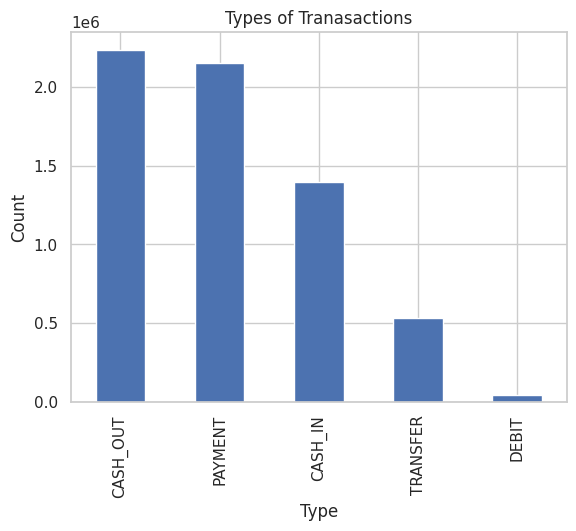

<Figure size 640x480 with 0 Axes>

In [ ]:
df['type'].value_counts().plot(kind='bar', title = 'Types of Tranasactions')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()
plt.savefig('Type_of_Transactions.png')

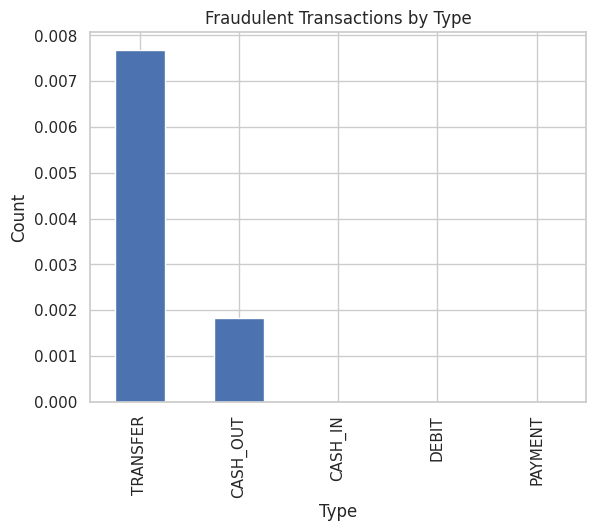

<Figure size 640x480 with 0 Axes>

In [ ]:
fraud_by_type = df.groupby(['type'])['isFraud'].mean().sort_values(ascending=False)

fraud_by_type.plot(kind='bar', title = 'Fraudulent Transactions by Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()
plt.savefig('Fraudulent_Transactions_by_Type.png')


In [ ]:
df['amount'].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


Though the mean is about 180,000 the standard deviation is almost by 600k with a max value of 9 million, so there a chance that there are some outliers

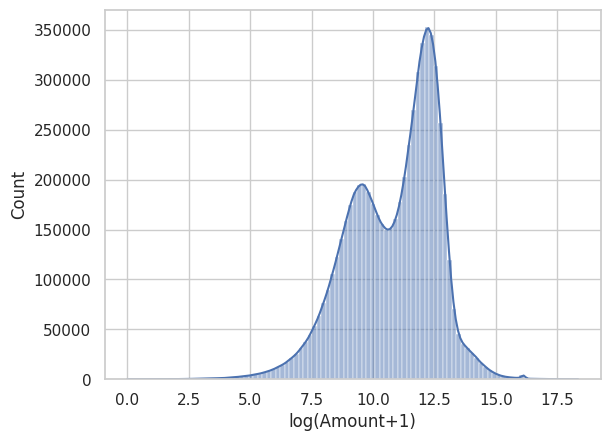

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.histplot(np.log1p(df['amount']), bins = 100, kde = True)
plt.xlabel('log(Amount+1)')
plt.ylabel('Count')
plt.show()
plt.savefig("distrbution_of_fraud_wrt_amount.png")

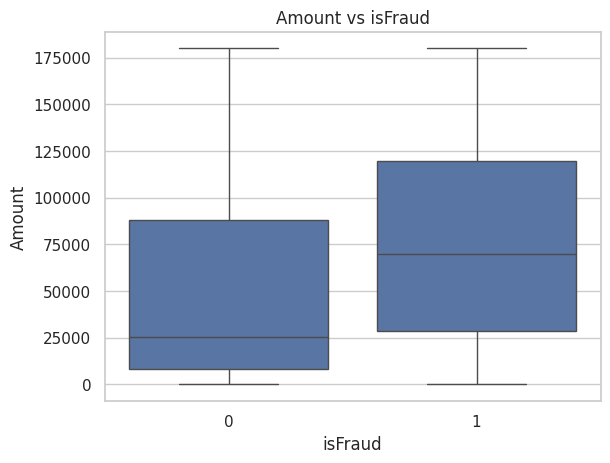

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.boxplot(data=df[df['amount']<180000], x='isFraud', y='amount') #taking ~180,000 as mean
plt.title("Amount vs isFraud")
plt.xlabel('isFraud')
plt.ylabel('Amount')
plt.show()
plt.savefig("Boxplot_Amount_v_isFraud.png")

taking box plot for below amount 180,000 we find that there are more frauds above the 30k and below 125k with a median of ~75k.

Non fraud transactions are between ~10k and 85k, however its median is 25k, this indicates that the distribution is skewed. So most of non fraud transactions are smaller transactions but there are larger legitimate transactions since the tail goes all the way up to 180k

step
1      16
2       8
3       4
4      10
5       6
       ..
739    10
740     6
741    22
742    14
743     8
Name: count, Length: 741, dtype: int64


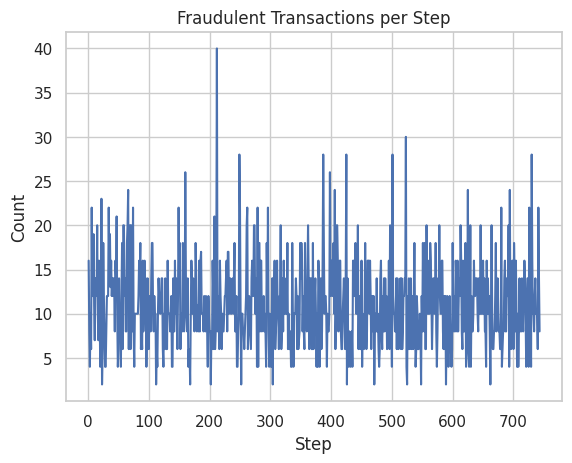

<Figure size 640x480 with 0 Axes>

In [ ]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
print(frauds_per_step)
frauds_per_step.plot(kind='line', title = 'Fraudulent Transactions per Step')
plt.xlabel('Step')
plt.ylabel('Count')
plt.show()
plt.savefig('Fraudlent_transaction_per_step.png')

In [ ]:
print(frauds_per_step.mean())
print(frauds_per_step.std())

11.083670715249662
4.972194634224828


Step is considered as a time interval in the dataset, we can see that regardless of the time interval there is little deviation with a mean of ~11 fraud transactions per step and a ~5 standard deviation. So time period dosen't affect frequency of transactions


In [ ]:
df.drop('step', inplace=True, axis=1)
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


So we dropping Step

In [ ]:
corr_matrix = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest' ,'newbalanceDest', 'isFraud']].corr()

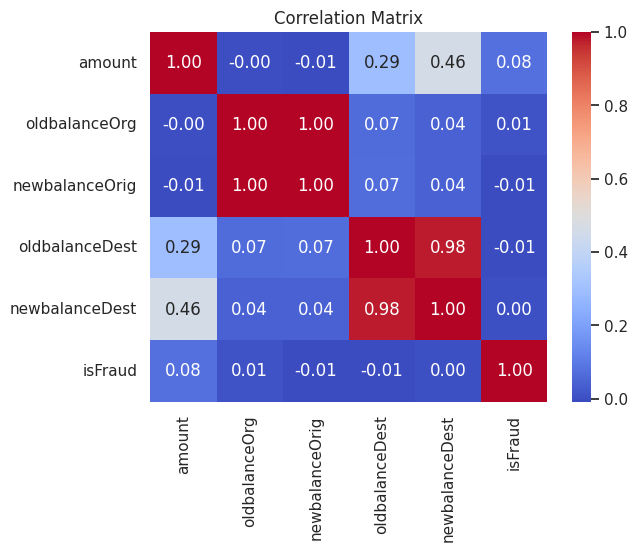

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()
plt.savefig('Correlation_matrix_')

In [ ]:
zero_after_transaction = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(["CASH_OUT", "TRANSFER"]))
]


In [ ]:
print(zero_after_transaction.value_counts().sum())

1188074


Data Preporcessing for logistic regression

---
need to apply smote, logisticregression(class_weight="balance") will not cut it

Synthetic minority oversampling technique from imblearn


---



Model performance **without** SMOTE and using only the scikit learn classweight.


---




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [ ]:
df.columns


Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis = 1)

In [ ]:
categorical = ['type']
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]


In [ ]:
y = df_model['isFraud']
X = df_model.drop('isFraud', axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

In [ ]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
  ]
)

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.95      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.95      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [ ]:
pipeline.score(X_test, y_test)

0.9468133148503813

Model achieves 94% accuracy but the precision is terrible

**Precision: (TP) / (TP + FP)** how many predected positvies were actually positives

**Recall: (TP) / (TP + FN)** how many of the actual positives were predicted correctly

**F1 Score: 2 x (Precision x Recall) / (precision + recall)**: Harmonic mean of precision and recall to represent both through a single value.


---



Problem may arise from the class_weight attribute.

The class_weight essentially adds a multiplier to the classes in an attempt to balance them.

Problem arises when the class imbalance is this severe, 1:0.0013 imbalance. hence the multiplier will be an exponential value

**class_weight calculation: n_samples / (n_classes * np.bincount(y))**

*   Non-fraud [0]: 6354407
*   Fraud [1]: 8213
*   Total: 6362620

In [ ]:
w_0 = 6354407 / (2 * 6354407)
print(w_0)
w_1 = 6354407 / (2 * 8213)
print(w_1)

0.5
386.85054182393765


Non Fraud weight: 0.5

Fraud weight: 386.85

Ratio of class weights: 0.5 : 386.85 ----> 1 : 773.3

Essentially Fraud classes have a multiplier of x773.3. This makes the model to be trigger happy and flags a lot more transactions as fraud.

This is the reason for the absolute garbage precision score. Due to the incredible amount of False Positives


In [ ]:
pipeline.score(X_test, y_test)

0.9468133148503813

The 94% accuracy is misleading since the prercision indicates a lot of false positives

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1804931  101391]
 [    131    2333]]


In [ ]:
y_test.value_counts()

,count
isFraud,
0,1906322
1,2464


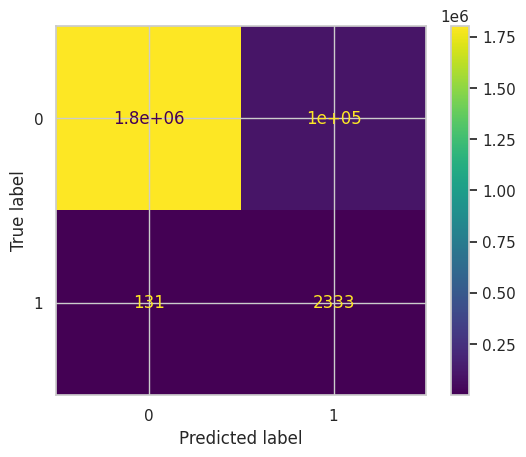

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=pipeline.classes_)
disp.plot()
plt.show()

Test dataset:
*   Fraud: 2464
*   Legit: 1906322

Confusion Matrix:

* True Frauds: 2,333 | False Frauds: 101,391
* True Legitimate: 1,804,931 | False Legitimate: 131



**USING SMOTE**

Using imblearn's SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, average_precision_score
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)


── Approximate train set counts after stratified 70/30 split ──────────────

Majority  (0): ~4,448,085

Minority  (1): ~5,749

Raw ratio    : ~773:1

── Step 1: SMOTE — oversample minority from ~5.7K → ~89K ─────────────────

sampling_strategy=0.02 means:

minority target = 0.02 × majority_count = 0.02 × 4,448,085 ≈ 89,000

We're creating ~83K synthetic fraud samples from ~5.7K real ones (~14× boost).

Keeping this conservative avoids hallucinating unrealistic fraud patterns.

In [ ]:
smote = SMOTE(
    sampling_strategy=0.02,
    k_neighbors=5,           # default; increase if minority cluster is tight
    random_state=42
)

── Step 2: RandomUnderSampler — shrink majority from ~4.4M → ~296K ────────

sampling_strategy=0.3 means:

minority / majority = 0.3  →  majority target = 89,000 / 0.3 ≈ 296,000

Final ratio ≈ 3.3:1 — manageable without discarding too much real signal.

In [ ]:
under = RandomUnderSampler(
    sampling_strategy=0.3,
    random_state=42
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

In [ ]:
pipeline = ImbPipeline([
    ('prep',  preprocessor),
    ('smote', smote),
    ('under', under),
    ('clf',   LogisticRegression(
                  max_iter=1000,
                  random_state=42
                  # ↑ dropped class_weight='balanced' — SMOTE is now handling
                  # the rebalancing. Keeping it would double-compensate.
              ))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.02)),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.3)),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print("without threshold")
print(classification_report(y_test, y_pred, digits=3))

print("with threshold of 0.98")
chosen = 0.99
y_pred_final = (y_proba >= chosen).astype(int)
print(classification_report(y_test, y_pred_final, digits=3))
# For severe imbalance, AUC-PR is more informative than ROC-AUC
print(f"Average Precision (AUC-PR) no threshold: {average_precision_score(y_test, y_proba):.4f}")
print(f"Average Precision (AUC-PR) with threshold: {average_precision_score(y_test, y_pred_final):.4f}")

without threshold
              precision    recall  f1-score   support

           0      1.000     0.982     0.991   1906322
           1      0.057     0.857     0.106      2464

    accuracy                          0.981   1908786
   macro avg      0.528     0.919     0.549   1908786
weighted avg      0.999     0.981     0.989   1908786

with threshold of 0.98
              precision    recall  f1-score   support

           0      0.999     1.000     0.999   1906322
           1      0.627     0.511     0.563      2464

    accuracy                          0.999   1908786
   macro avg      0.813     0.755     0.781   1908786
weighted avg      0.999     0.999     0.999   1908786

Average Precision (AUC-PR) no threshold: 0.5705
Average Precision (AUC-PR) with threshold: 0.3212


Even with SMOTE the precision for fraud only is 5%. simply not enough

Random Forest:

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (classification_report, average_precision_score,
                             precision_recall_curve)
import numpy as np
import matplotlib.pyplot as plt

categorical = ['type']
numeric     = ["amount", "oldbalanceOrg", "newbalanceOrig",
               "oldbalanceDest", "newbalanceDest"]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

smote = SMOTE(sampling_strategy=0.02, k_neighbors=5, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.3, random_state=42)

pipeline_rf = ImbPipeline([
    ('prep',  preprocessor),
    ('smote', smote),
    ('under', under),
    ('clf',   RandomForestClassifier(
                  n_estimators=300,
                  max_depth=20,           # unconstrained trees overfit on synthetic data
                  min_samples_leaf=10,    # smooths decision boundaries
                  class_weight='balanced_subsample',  # reweights per bootstrap sample
                  n_jobs=-1,              # use all CPU cores — RF is parallelisable
                  random_state=42
              ))
])

pipeline_rf.fit(X_train, y_train)

y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_rf  = pipeline_rf.predict(X_test)

print("=" * 50)
print("Random Forest — default 0.5 threshold")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_rf):.4f}")

# ── Feature importance (top 10) ──────────────────────────────────────────────
# Extract feature names after one-hot encoding
ohe_features = (pipeline_rf.named_steps['prep']
                .named_transformers_['cat']
                .get_feature_names_out(['type']).tolist())
feature_names = numeric + ohe_features

importances = pipeline_rf.named_steps['clf'].feature_importances_
top_idx     = np.argsort(importances)[::-1][:10]

print("\nTop 10 features by importance:")
for i in top_idx:
    print(f"  {feature_names[i]:<30} {importances[i]:.4f}")

Random Forest — default 0.5 threshold
              precision    recall  f1-score   support

           0      1.000     0.996     0.998   1906322
           1      0.250     0.993     0.400      2464

    accuracy                          0.996   1908786
   macro avg      0.625     0.994     0.699   1908786
weighted avg      0.999     0.996     0.997   1908786

AUC-PR: 0.9494

Top 10 features by importance:
  oldbalanceOrg                  0.3461
  newbalanceOrig                 0.1928
  amount                         0.1846
  type_TRANSFER                  0.0812
  type_PAYMENT                   0.0606
  newbalanceDest                 0.0544
  oldbalanceDest                 0.0418
  type_CASH_OUT                  0.0383
  type_DEBIT                     0.0003


In [ ]:
categorical = ['type']
numeric     = ["amount", "oldbalanceOrg", "newbalanceOrig",
               "oldbalanceDest", "newbalanceDest"]

In [ ]:
pipeline_rf = ImbPipeline([
    ('prep',  preprocessor),
    ('smote', smote),
    ('under', under),
    ('clf',   RandomForestClassifier(
                  n_estimators=300,
                  max_depth=20,           # unconstrained trees overfit on synthetic data
                  min_samples_leaf=10,    # smooths decision boundaries
                  class_weight='balanced_subsample',  # reweights per bootstrap sample
                  n_jobs=-1,              # use all CPU cores — RF is parallelisable
                  random_state=42
              ))
])

In [ ]:
pipeline_rf.fit(X_train, y_train)

In [ ]:
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]
y_pred_rf  = pipeline_rf.predict(X_test)

In [ ]:
print("=" * 50)
print("Random Forest — default 0.5 threshold")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, digits=3))
print(f"AUC-PR: {average_precision_score(y_test, y_proba_rf):.4f}")

This is a really important distinction to understand. The short answer is: precision of 0.255 is the model's performance at one specific threshold (0.5).

AUC-PR summarises performance across all thresholds.The key insight is that AUC-PR and the precision in your classification report are measuring fundamentally different things.

The report shows a single snapshot; AUC-PR shows the whole picture.


Think of it like a weather forecast. Saying "it rained on Tuesday" (one threshold) tells you nothing about the forecaster's overall skill.

AUC-PR asks: "across every possible confidence threshold from 0.0 to 1.0, how well does the model rank fraud above non-fraud?"

The 0.9457 means the model is excellent at ranking — it assigns much higher probabilities to real fraud. But at the specific cutoff of 0.5, enough false positives still sneak through to drag precision to 0.255.

There's no single "optimal" threshold — it depends on what businesses actually penalises more: missing fraud or blocking legit transactions.


From JPMorgan: false positive losses amount to 19% of the total cost of fraud, while actual fraud losses represent only 7%. jpmorgan This sounds like FPs are cheaper per event — but it's reversed at aggregate scale because there are so many more of them.
https://www.jpmorgan.com/insights/payments/data-intelligence/cnp-fraud-prevention-combat-chargebacks


From Flagright: false positives cost financial institutions $500–$1,500 per investigation on average, with annual costs reaching tens of millions for large institutions at 95% false positive rates. flagright This is the manual review cost — for automated pipelines it's far lower.
https://www.flagright.com/post/understanding-false-positives-in-transaction-monitoring

From Kount (most directly applicable): for a high-value transaction business, the estimated cost of false negatives is -$2,500, while the average loss of false positives is -$100 covering investigation costs and delays.
https://kount.com/blog/precision-recall-when-conventional-fraud-metrics-fall-short

kount For a low-value merchant, the ratio flips — the estimated cost of false positives is -$150 (accounting for potential customer loss and reputational impact), while false negatives cost -$60. kount

From MDPI (credit card fraud research specifically): credit card fraud losses are projected to exceed $40 billion annually by 2027, with cost-sensitive approaches using C_FN/C_FP ratios set by business constraints — for example, 50:1. mdpi
https://www.mdpi.com/2076-3417/15/21/11787

From Getmonetizely: LexisNexis Risk Solutions estimates that for every $1 of fraud, companies incur $3.75 in associated costs, with manual review processes representing a substantial portion. getmonetizely
https://www.getmonetizely.com/articles/pricing-ai-fraud-detection-balancing-false-positive-rates-against-savings-generated

In [ ]:
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np

In [ ]:
y_proba = pipeline_rf.predict_proba(X_test)[:, 1]
prec_vals, rec_vals, thresholds = precision_recall_curve(y_test, y_proba)
print(len(thresholds))

261248


In [ ]:
cost_fn = 500   # cost of missing a fraud case
cost_fp = 8    # cost of a false alert (review time, customer friction)
cycles = 0
costs = []
for i, t in enumerate(thresholds):
    y_pred_t = (y_proba >= t).astype(int)
    tp = int(((y_pred_t==1) & (y_test==1)).sum())
    fp = int(((y_pred_t==1) & (y_test==0)).sum())
    fn = int(((y_pred_t==0) & (y_test==1)).sum())
    costs.append(fn * cost_fn + fp * cost_fp)
    cycles += 1
    print(cycles)

best_cost_threshold = thresholds[np.argmin(costs)]

Streaming output truncated to the last 5000 lines.
245672
245673
245674
245675
245676
245677
245678
245679
245680
245681
245682
245683
245684
245685
245686
245687
245688
245689
245690
245691
245692
245693
245694
245695
245696
245697
245698
245699
245700
245701
245702
245703
245704
245705
245706
245707
245708
245709
245710
245711
245712
245713
245714
245715
245716
245717
245718
245719
245720
245721
245722
245723
245724
245725
245726
245727
245728
245729
245730
245731
245732
245733
245734
245735
245736
245737
245738
245739
245740
245741
245742
245743
245744
245745
245746
245747
245748
245749
245750
245751
245752
245753
245754
245755
245756
245757
245758
245759
245760
245761
245762
245763
245764
245765
245766
245767
245768
245769
245770
245771
245772
245773
245774
245775
245776
245777
245778
245779
245780
245781
245782
245783
245784
245785
245786
245787
245788
245789
245790
245791
245792
245793
245794
245795
245796
245797
245798
245799
245800
245801
245802
245803
245804
245805
245806
2458

In [ ]:
chosen = 0.971
print(f"Chosen threshold: {chosen:.3f}")
y_pred_final = (y_proba >= chosen).astype(int)
print(f"AUC-PR which represents for all possible threshold values: {average_precision_score(y_test, y_proba):.4f}")
print(classification_report(y_test, y_pred_final, digits=3))


# ── Sanity check: count flags ─────────────────────────────────────────────────
flags = y_pred_final.sum()
real_fraud = int(((y_pred_final==1) & (y_test==1)).sum())
print(f"Flagged {flags:,} transactions — {real_fraud:,} real fraud, "
      f"{flags-real_fraud:,} false alerts")
print(f"1 in {flags//real_fraud if real_fraud else 'N/A'} flags is real fraud")

Chosen threshold: 0.971
AUC-PR which represents for all possible threshold values: 0.9494
              precision    recall  f1-score   support

           0      1.000     1.000     1.000   1906322
           1      0.943     0.818     0.876      2464

    accuracy                          1.000   1908786
   macro avg      0.972     0.909     0.938   1908786
weighted avg      1.000     1.000     1.000   1908786

Flagged 2,136 transactions — 2,015 real fraud, 121 false alerts
1 in 1 flags is real fraud


In [ ]:
print(classification_report(y_test, y_pred_final, digits=3))


              precision    recall  f1-score   support

           0      1.000     1.000     1.000   1906322
           1      0.943     0.818     0.876      2464

    accuracy                          1.000   1908786
   macro avg      0.972     0.909     0.938   1908786
weighted avg      1.000     1.000     1.000   1908786



In [ ]:
pipeline_rf.score(X_test, y_test)

0.996247876922819

AUC-PR is a property of the model, not a threshold. It is computed from y_proba (the full probability scores) by sweeping every possible threshold and measuring the area under the resulting precision-recall curve. It summarises the model's ranking ability across all operating points.

PLOTS


In [ ]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)
import matplotlib.gridspec as gridspec


In [ ]:
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

<Figure size 1400x600 with 0 Axes>

Shared Values

In [ ]:
roc_auc = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
prec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)

In [ ]:
chosen = 0.971

# ROC marker — closest threshold index
roc_idx = np.argmin(np.abs(roc_thresholds - chosen))
roc_fpr_pt, roc_tpr_pt = fpr[roc_idx], tpr[roc_idx]

# PR marker
pr_idx  = np.argmin(np.abs(pr_thresholds - chosen))
pr_rec_pt, pr_prec_pt = rec[pr_idx], prec[pr_idx]

PLOT 1 ROC Curve

In [ ]:
ax1 = fig.add_subplot(gs[0])

ax1.plot(fpr, tpr, color="#1E88E5", lw=2.2,
         label=f"Random Forest  (AUC-ROC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], color="#90A4AE", lw=1, linestyle="--",
         label="Random classifier (AUC = 0.50)")
# chosen threshold marker
ax1.scatter(roc_fpr_pt, roc_tpr_pt, color="#E53935", s=100, zorder=5,
            label=f"Threshold = {chosen}  (TPR={roc_tpr_pt:.3f}, FPR={roc_fpr_pt:.4f})")
ax1.annotate(
    f"  t = {chosen}\n  TPR = {roc_tpr_pt:.3f}\n  FPR = {roc_fpr_pt:.4f}",
    xy=(roc_fpr_pt, roc_tpr_pt),
    xytext=(roc_fpr_pt + 0.08, roc_tpr_pt - 0.12),
    fontsize=9, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1),
)

ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])
ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate", fontsize=11)
ax1.set_title("ROC Curve — Random Forest", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.25)

PLOT 2 Area Under Precision Recall : AUC-PR

In [ ]:
ax2 = fig.add_subplot(gs[1])

# baseline = fraud prevalence in test set
baseline = y_test.mean()

ax2.plot(rec, prec, color="#43A047", lw=2.2,
         label=f"Random Forest  (AUC-PR = {ap:.4f})")
ax2.axhline(baseline, color="#90A4AE", lw=1, linestyle="--",
            label=f"No-skill baseline  (prevalence = {baseline:.4f})")

In [ ]:
# chosen threshold marker
ax2.scatter(pr_rec_pt, pr_prec_pt, color="#E53935", s=100, zorder=5,
            label=f"Threshold = {chosen}  (P={pr_prec_pt:.3f}, R={pr_rec_pt:.3f})")
ax2.annotate(
    f"  t = {chosen}\n  Precision = {pr_prec_pt:.3f}\n  Recall    = {pr_rec_pt:.3f}",
    xy=(pr_rec_pt, pr_prec_pt),
    xytext=(pr_rec_pt - 0.25, pr_prec_pt - 0.18),
    fontsize=9, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1),
)

ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.05])
ax2.set_xlabel("Recall", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.set_title("Precision-Recall Curve — Random Forest", fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(alpha=0.25)

In [ ]:
plt.show()

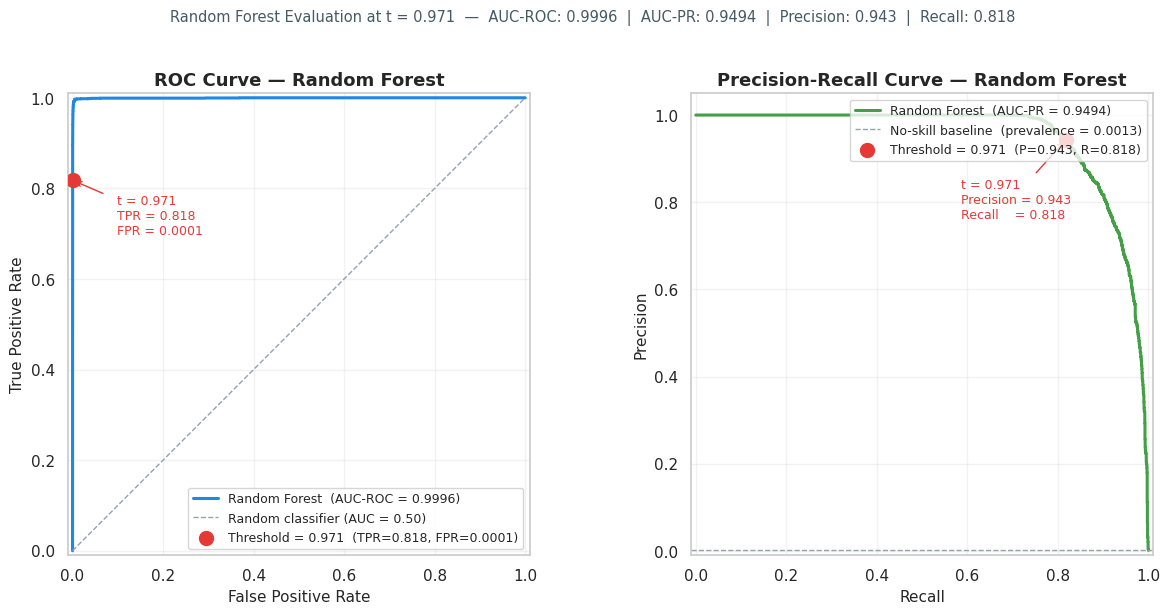

Saved → rf_roc_pr_curves.png


In [ ]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── shared values ─────────────────────────────────────────────────────────────
roc_auc = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)

fpr, tpr, roc_thresholds      = roc_curve(y_test, y_proba)
prec, rec, pr_thresholds      = precision_recall_curve(y_test, y_proba)

# ── find marker positions for chosen threshold ────────────────────────────────
chosen = 0.971

# ROC marker — closest threshold index
roc_idx = np.argmin(np.abs(roc_thresholds - chosen))
roc_fpr_pt, roc_tpr_pt = fpr[roc_idx], tpr[roc_idx]

# PR marker
pr_idx  = np.argmin(np.abs(pr_thresholds - chosen))
pr_rec_pt, pr_prec_pt = rec[pr_idx], prec[pr_idx]

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — ROC CURVE
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

ax1.plot(fpr, tpr, color="#1E88E5", lw=2.2,
         label=f"Random Forest  (AUC-ROC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], color="#90A4AE", lw=1, linestyle="--",
         label="Random classifier (AUC = 0.50)")

# chosen threshold marker
ax1.scatter(roc_fpr_pt, roc_tpr_pt, color="#E53935", s=100, zorder=5,
            label=f"Threshold = {chosen}  (TPR={roc_tpr_pt:.3f}, FPR={roc_fpr_pt:.4f})")
ax1.annotate(
    f"  t = {chosen}\n  TPR = {roc_tpr_pt:.3f}\n  FPR = {roc_fpr_pt:.4f}",
    xy=(roc_fpr_pt, roc_tpr_pt),
    xytext=(roc_fpr_pt + 0.08, roc_tpr_pt - 0.12),
    fontsize=9, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1),
)

ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.01])
ax1.set_xlabel("False Positive Rate", fontsize=11)
ax1.set_ylabel("True Positive Rate", fontsize=11)
ax1.set_title("ROC Curve — Random Forest", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.25)

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — PRECISION-RECALL CURVE
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])

# baseline = fraud prevalence in test set
baseline = y_test.mean()

ax2.plot(rec, prec, color="#43A047", lw=2.2,
         label=f"Random Forest  (AUC-PR = {ap:.4f})")
ax2.axhline(baseline, color="#90A4AE", lw=1, linestyle="--",
            label=f"No-skill baseline  (prevalence = {baseline:.4f})")

# chosen threshold marker
ax2.scatter(pr_rec_pt, pr_prec_pt, color="#E53935", s=100, zorder=5,
            label=f"Threshold = {chosen}  (P={pr_prec_pt:.3f}, R={pr_rec_pt:.3f})")
ax2.annotate(
    f"  t = {chosen}\n  Precision = {pr_prec_pt:.3f}\n  Recall    = {pr_rec_pt:.3f}",
    xy=(pr_rec_pt, pr_prec_pt),
    xytext=(pr_rec_pt - 0.25, pr_prec_pt - 0.18),
    fontsize=9, color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1),
)

ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.05])
ax2.set_xlabel("Recall", fontsize=11)
ax2.set_ylabel("Precision", fontsize=11)
ax2.set_title("Precision-Recall Curve — Random Forest", fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(alpha=0.25)

# ─────────────────────────────────────────────────────────────────────────────
# SHARED FOOTER
# ─────────────────────────────────────────────────────────────────────────────
fig.suptitle(
    f"Random Forest Evaluation at t = {chosen}  —  "
    f"AUC-ROC: {roc_auc:.4f}  |  AUC-PR: {ap:.4f}  |  "
    f"Precision: {pr_prec_pt:.3f}  |  Recall: {pr_rec_pt:.3f}",
    fontsize=10.5, y=1.02, color="#455A64"
)

plt.tight_layout()
plt.savefig("rf_roc_pr_curves.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved → rf_roc_pr_curves.png")

when we call:
pythonfpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
```
sklearn doesn't evaluate the curve at evenly spaced thresholds like 0.1, 0.2, 0.3... It uses **every unique predicted probability in `y_proba` as a threshold candidate**. So if your model outputs 1,590,000 test predictions, `roc_thresholds` might contain ~8,000+ distinct probability values like:
```
[0.99983, 0.99971, 0.99964, 0.99950, ... 0.00021, 0.00008]
The chosen value of 0.971 almost certainly does not appear exactly in that array. So you can't do:
pythonroc_thresholds.index(0.971)  # won't find it

Instead, `np.argmin(np.abs(roc_thresholds - chosen))` finds the index of whichever threshold in the array is **numerically closest** to 0.971 — say `0.97103` — and uses its corresponding `fpr` and `tpr` values as the marker coordinates on the curve.

roc_thresholds: [..., 0.97245, 0.97103, 0.96988, ...]
                                  
                                  ↑
                     closest to 0.971 → use this index
                     fpr[this_idx], tpr[this_idx] → red dot position

The PR marker works identically but has one additional subtlety worth understanding.
pythonprec, rec, pr_thresholds = precision_recall_curve(y_test, y_proba)

`pr_thresholds` is also built from the unique values in `y_proba`, but there is an asymmetry: **`prec` and `rec` have one more element than `pr_thresholds`**. sklearn appends a final point at recall=0, precision=1 (the top-left anchor of the curve) that has no corresponding threshold. So:

len(pr_thresholds) = N
len(prec)          = N + 1
len(rec)           = N + 1
```

The same closest-index lookup applies:
```
pr_thresholds: [..., 0.97245, 0.97103, 0.96988, ...]
                                  
                                  ↑
               closest to 0.971 → pr_idx
               rec[pr_idx], prec[pr_idx] → red dot position on PR curve

Because `pr_thresholds[i]` corresponds to `prec[i]` and `rec[i]` (the extra element is at index N, beyond any threshold), the indexing is safe as long as `pr_idx` is found within the threshold array — which it always will be since we're searching within `pr_thresholds` itself.

---

So to summarise the full picture:

y_proba contains N unique values
         **↓**

roc_curve / precision_recall_curve sweep ALL N values as candidate thresholds
         **↓**

roc_thresholds / pr_thresholds = those N unique probabilities (descending)
         **↓**

0.971 is OUR chosen operating point — one specific location on the curve
         **↓**

argmin(|thresholds - 0.971|) finds the nearest actual threshold in the sweep
         **↓**

its index gives the (fpr, tpr) or (precision, recall) at that point → red dot
The dot is not changing the AUC — it's just a visual marker saying "out of all the threshold values sklearn evaluated, here is the one closest to where you decided to operate."

In [ ]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, accuracy_score, f1_score,
    precision_score, recall_score
)

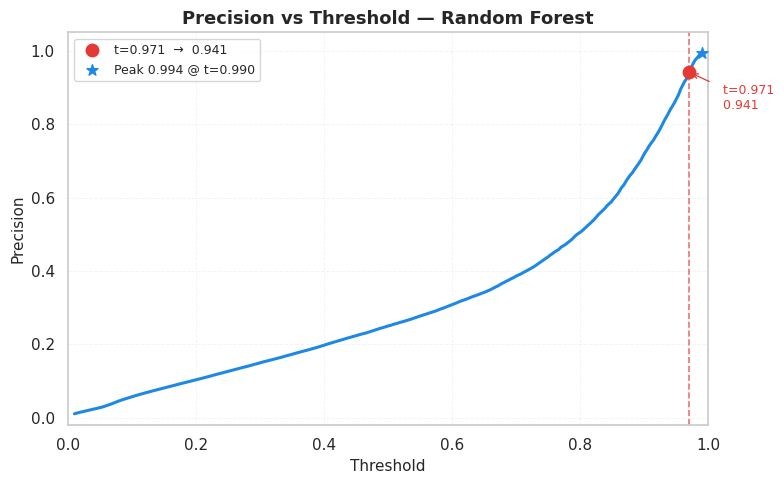

In [ ]:
#For Precision VS Threshold
fig, ax = plt.subplots(figsize=(8, 5))

thresholds  = np.linspace(0.01, 0.99, 300)
precisions  = [precision_score(y_test, (y_proba >= t).astype(int), zero_division=0)
               for t in thresholds]
precisions  = np.array(precisions)

best_idx    = np.argmax(precisions)
chosen      = 0.971
chosen_idx  = np.argmin(np.abs(thresholds - chosen))

ax.plot(thresholds, precisions, color="#1E88E5", lw=2.2)
ax.axvline(chosen, color="#E53935", lw=1.2, linestyle="--", alpha=0.7)
ax.scatter(chosen, precisions[chosen_idx], color="#E53935", s=80, zorder=5,
           label=f"t={chosen}  →  {precisions[chosen_idx]:.3f}")
ax.scatter(thresholds[best_idx], precisions[best_idx], color="#1E88E5",
           s=70, marker="*", zorder=6,
           label=f"Peak {precisions[best_idx]:.3f} @ t={thresholds[best_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  {precisions[chosen_idx]:.3f}",
            xy=(chosen, precisions[chosen_idx]),
            xytext=(chosen + 0.04, precisions[chosen_idx] - 0.1),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision vs Threshold — Random Forest", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([0, 1]);  ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.savefig("plot_precision.png", dpi=180, bbox_inches="tight")
plt.show()

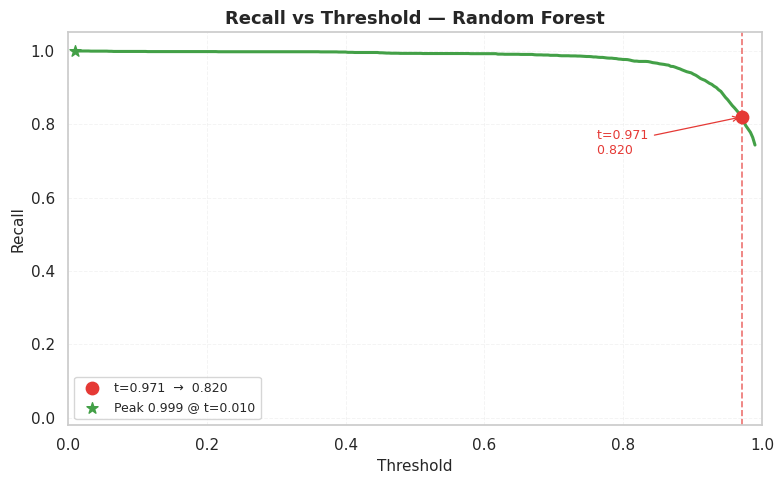

In [ ]:
#Recall VS Threshold
fig, ax = plt.subplots(figsize=(8, 5))

thresholds = np.linspace(0.01, 0.99, 300)
recalls    = [recall_score(y_test, (y_proba >= t).astype(int), zero_division=0)
              for t in thresholds]
recalls    = np.array(recalls)

best_idx   = np.argmax(recalls)
chosen     = 0.971
chosen_idx = np.argmin(np.abs(thresholds - chosen))

ax.plot(thresholds, recalls, color="#43A047", lw=2.2)
ax.axvline(chosen, color="#E53935", lw=1.2, linestyle="--", alpha=0.7)
ax.scatter(chosen, recalls[chosen_idx], color="#E53935", s=80, zorder=5,
           label=f"t={chosen}  →  {recalls[chosen_idx]:.3f}")
ax.scatter(thresholds[best_idx], recalls[best_idx], color="#43A047",
           s=70, marker="*", zorder=6,
           label=f"Peak {recalls[best_idx]:.3f} @ t={thresholds[best_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  {recalls[chosen_idx]:.3f}",
            xy=(chosen, recalls[chosen_idx]),
            xytext=(chosen - 0.22, recalls[chosen_idx] - 0.1),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Recall", fontsize=11)
ax.set_title("Recall vs Threshold — Random Forest", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([0, 1]);  ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.savefig("plot_recall.png", dpi=180, bbox_inches="tight")
plt.show()

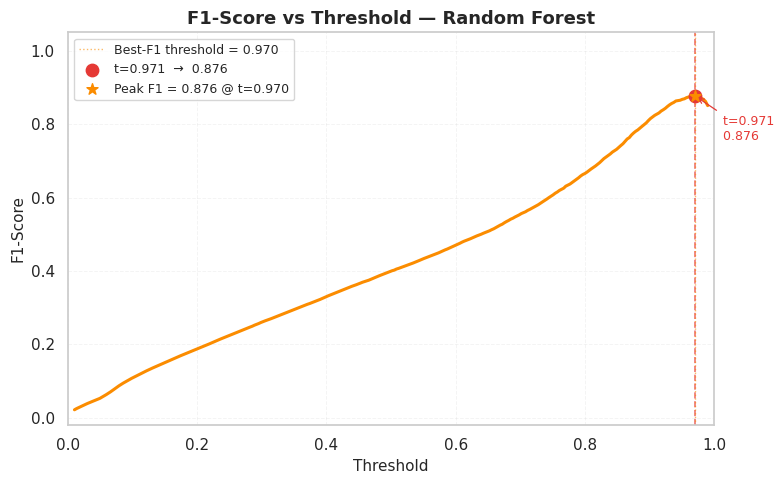

In [ ]:
#F1-Score VS Threshold
fig, ax = plt.subplots(figsize=(8, 5))

thresholds = np.linspace(0.01, 0.99, 300)
f1s        = [f1_score(y_test, (y_proba >= t).astype(int), zero_division=0)
              for t in thresholds]
f1s        = np.array(f1s)

best_idx   = np.argmax(f1s)
chosen     = 0.971
chosen_idx = np.argmin(np.abs(thresholds - chosen))

ax.plot(thresholds, f1s, color="#FB8C00", lw=2.2)
ax.axvline(chosen, color="#E53935", lw=1.2, linestyle="--", alpha=0.7)
ax.axvline(thresholds[best_idx], color="#FB8C00", lw=1, linestyle=":",
           alpha=0.6, label=f"Best-F1 threshold = {thresholds[best_idx]:.3f}")
ax.scatter(chosen, f1s[chosen_idx], color="#E53935", s=80, zorder=5,
           label=f"t={chosen}  →  {f1s[chosen_idx]:.3f}")
ax.scatter(thresholds[best_idx], f1s[best_idx], color="#FB8C00",
           s=70, marker="*", zorder=6,
           label=f"Peak F1 = {f1s[best_idx]:.3f} @ t={thresholds[best_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  {f1s[chosen_idx]:.3f}",
            xy=(chosen, f1s[chosen_idx]),
            xytext=(chosen + 0.03, f1s[chosen_idx] - 0.12),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_title("F1-Score vs Threshold — Random Forest", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([0, 1]);  ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.savefig("plot_f1.png", dpi=180, bbox_inches="tight")
plt.show()

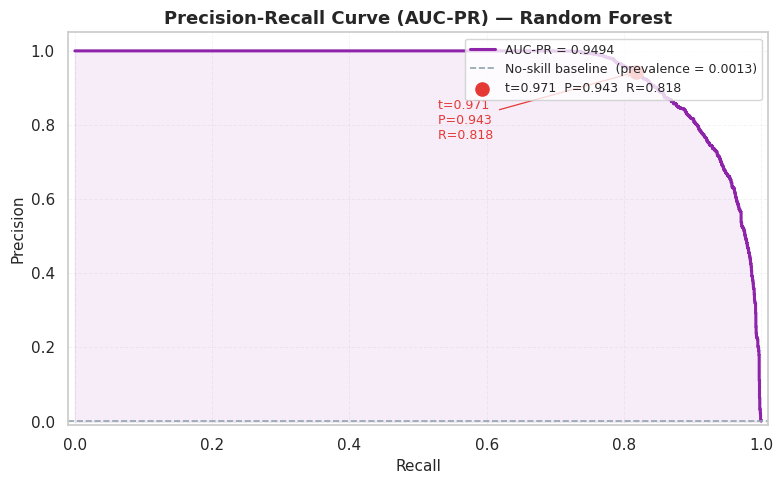

In [ ]:
#AUC-PR Curve
fig, ax = plt.subplots(figsize=(8, 5))

pr_prec, pr_rec, pr_thresh = precision_recall_curve(y_test, y_proba)
ap       = average_precision_score(y_test, y_proba)
baseline = y_test.mean()

chosen   = 0.971
pr_idx   = np.argmin(np.abs(pr_thresh - chosen))

ax.plot(pr_rec, pr_prec, color="#8E24AA", lw=2.2,
        label=f"AUC-PR = {ap:.4f}")
ax.fill_between(pr_rec, pr_prec, alpha=0.08, color="#8E24AA")
ax.axhline(baseline, color="#90A4AE", lw=1.2, linestyle="--",
           label=f"No-skill baseline  (prevalence = {baseline:.4f})")
ax.scatter(pr_rec[pr_idx], pr_prec[pr_idx], color="#E53935", s=90, zorder=5,
           label=f"t={chosen}  P={pr_prec[pr_idx]:.3f}  R={pr_rec[pr_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  P={pr_prec[pr_idx]:.3f}\n  R={pr_rec[pr_idx]:.3f}",
            xy=(pr_rec[pr_idx], pr_prec[pr_idx]),
            xytext=(pr_rec[pr_idx] - 0.3, pr_prec[pr_idx] - 0.18),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve (AUC-PR) — Random Forest",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([-0.01, 1.01]);  ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.savefig("plot_aucpr.png", dpi=180, bbox_inches="tight")
plt.show()

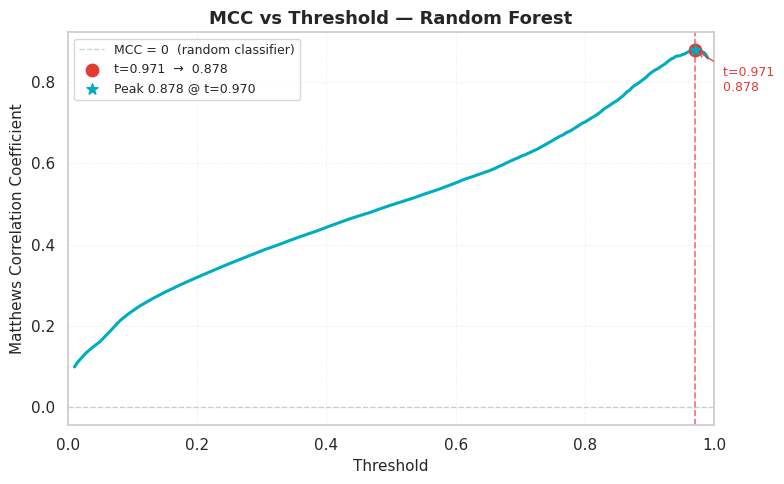

In [ ]:
#MCC VS Thresholds
fig, ax = plt.subplots(figsize=(8, 5))

thresholds = np.linspace(0.01, 0.99, 300)
mccs       = [matthews_corrcoef(y_test, (y_proba >= t).astype(int))
              for t in thresholds]
mccs       = np.array(mccs)

best_idx   = np.argmax(mccs)
chosen     = 0.971
chosen_idx = np.argmin(np.abs(thresholds - chosen))

ax.plot(thresholds, mccs, color="#00ACC1", lw=2.2)
ax.axhline(0, color="#90A4AE", lw=1, linestyle="--", alpha=0.5,
           label="MCC = 0  (random classifier)")
ax.axvline(chosen, color="#E53935", lw=1.2, linestyle="--", alpha=0.7)
ax.scatter(chosen, mccs[chosen_idx], color="#E53935", s=80, zorder=5,
           label=f"t={chosen}  →  {mccs[chosen_idx]:.3f}")
ax.scatter(thresholds[best_idx], mccs[best_idx], color="#00ACC1",
           s=70, marker="*", zorder=6,
           label=f"Peak {mccs[best_idx]:.3f} @ t={thresholds[best_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  {mccs[chosen_idx]:.3f}",
            xy=(chosen, mccs[chosen_idx]),
            xytext=(chosen + 0.03, mccs[chosen_idx] - 0.1),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Matthews Correlation Coefficient", fontsize=11)
ax.set_title("MCC vs Threshold — Random Forest", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig("plot_mcc.png", dpi=180, bbox_inches="tight")
plt.show()

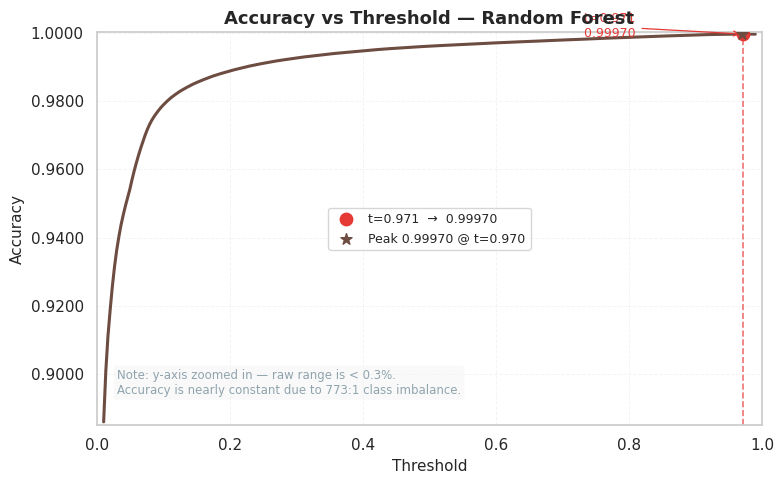

In [ ]:
#Accuracy VS Threshold
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8, 5))

thresholds = np.linspace(0.01, 0.99, 300)
accuracies = [accuracy_score(y_test, (y_proba >= t).astype(int))
              for t in thresholds]
accuracies = np.array(accuracies)

best_idx   = np.argmax(accuracies)
chosen     = 0.971
chosen_idx = np.argmin(np.abs(thresholds - chosen))

ax.plot(thresholds, accuracies, color="#6D4C41", lw=2.2)
ax.axvline(chosen, color="#E53935", lw=1.2, linestyle="--", alpha=0.7)
ax.scatter(chosen, accuracies[chosen_idx], color="#E53935", s=80, zorder=5,
           label=f"t={chosen}  →  {accuracies[chosen_idx]:.5f}")
ax.scatter(thresholds[best_idx], accuracies[best_idx], color="#6D4C41",
           s=70, marker="*", zorder=6,
           label=f"Peak {accuracies[best_idx]:.5f} @ t={thresholds[best_idx]:.3f}")
ax.annotate(f"  t={chosen}\n  {accuracies[chosen_idx]:.5f}",
            xy=(chosen, accuracies[chosen_idx]),
            xytext=(chosen - 0.25, accuracies[chosen_idx] - 0.001),
            fontsize=9, color="#E53935",
            arrowprops=dict(arrowstyle="->", color="#E53935", lw=0.9))

# zoom y-axis — without this the line looks completely flat
y_min = accuracies.min() - 0.001
y_max = accuracies.max() + 0.0005
ax.set_ylim([y_min, y_max])
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Accuracy vs Threshold — Random Forest", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.22, linestyle="--", linewidth=0.7)
ax.set_xlim([0, 1])

# annotation explaining why accuracy is nearly flat
ax.text(0.03, y_min + (y_max - y_min) * 0.08,
        "Note: y-axis zoomed in — raw range is < 0.3%.\n"
        "Accuracy is nearly constant due to 773:1 class imbalance.",
        fontsize=8.5, color="#90A4AE",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5", alpha=0.5))

plt.tight_layout()
plt.savefig("plot_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

Precision will start near zero at low thresholds (the model flags almost everything, drowning in false positives) and climb sharply as the threshold rises. At 0.971 it should sit around 0.924.

Recall does the opposite — near 1.0 at low thresholds and falls as you raise the bar. The drop will be gradual until around 0.85–0.95 where it falls more steeply, reflecting the model's well-separated score distribution.

F1 will show a clear peak somewhere in the mid-range (likely 0.55–0.70) then decline. Your chosen 0.971 will sit to the right of the peak — you're trading some F1 optimality for higher precision, which is a deliberate operational decision.

MCC is the most honest of the five threshold-dependent metrics. It will peak somewhere near the F1 peak. If the MCC at your chosen threshold is still reasonably high (say above 0.85), it confirms the model is making genuinely balanced decisions rather than just exploiting class asymmetry.

Accuracy will look almost flat near 0.999 across the whole range due to the 773:1 imbalance — this is exactly why it was described as a misleading metric. The y-axis is zoomed in automatically so you can actually see the tiny variation that exists.

AUC-PR panel shows the full curve with a shaded fill, the no-skill baseline near zero, and the red dot marking your operating point at 0.971.

In [ ]:
#saving the Random Forest Model
import joblib
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
save_path_joblib = '/content/drive/MyDrive/Minor_Project_Data/model_rf.joblib'
save_path_pkl = '/content/drive/MyDrive/Minor_Project_Data/model_rf.pkl'

joblib.dump(pipeline_rf, save_path_joblib)
joblib.dump(pipeline_rf, save_path_pkl)

['/content/drive/MyDrive/Minor_Project_Data/model_rf.pkl']

    ┌─────────────────────────────────────────┬────────┬──────────────────────┐
    │ Rule                                    │ Weight │ Rationale            │
    ├─────────────────────────────────────────┼────────┼──────────────────────┤
    │ Account fully drained after transaction │  0.55  │ Strongest EDA signal │
    │ Transaction type is CASH_OUT/TRANSFER   │  0.10  │ Only fraud-bearing   │
    │ Amount > 80% of origin balance          │  0.20  │ Near-complete drain  │
    │ Amount 50–80% of origin balance         │  0.10  │ Partial drain        │
    │ Destination balance inconsistency       │  0.15  │ Bookkeeping mismatch │
    │ Zero origin balance + large amount      │  0.10  │ Mule account signal  │
    ├─────────────────────────────────────────┼────────┼──────────────────────┤
    │ Maximum possible score (capped at 1.0)  │  1.00  │                      │
    └─────────────────────────────────────────┴────────┴──────────────────────┘